In [2]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/Users/layvvs/Desktop/HSE/Studying/year-project/hse-ai-year-project-2025/checkpoint-6-bmyakin/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка данных и их объединение

Пока работаем только с позитивами, поэтому дизлайки выкидываем

In [3]:
likes = load_from_disk('yambda-dataset/yambda_likes')
listens = load_from_disk('yambda-dataset/yambda_listens')

likes_table = likes.data.table
listens_table = listens.data.table


likes_df: pd.DataFrame = pd.DataFrame.from_arrow(likes_table)
listens_df: pd.DataFrame = pd.DataFrame.from_arrow(listens_table)

likes_df['event_type'] = 'like'
listens_df['event_type'] = 'listen'

yambda_df = pd.concat([likes_df, listens_df], ignore_index=True)

yambda_df = yambda_df.sort_values('timestamp')

yambda_df

,uid,timestamp,item_id,is_organic,event_type,played_ratio_pct,track_length_seconds
22879986,468300,0,7400764,0,listen,100.0,225.0
17033976,347600,5,3415205,0,listen,100.0,250.0
44773176,942900,10,6728180,0,listen,1.0,270.0
1388942,12700,15,8932363,0,listen,100.0,245.0
12164540,243500,15,5283544,1,listen,100.0,195.0
...,...,...,...,...,...,...,...
30815427,645300,25999995,1172812,1,listen,100.0,120.0
9620970,190700,25999995,875069,0,listen,0.0,235.0
7523389,144700,26000000,6281650,0,listen,6.0,205.0
42998457,903600,26000000,8370890,1,listen,6.0,220.0


Разобьем данные по стратегии `Global Temporal Split`. Берем для этого последний год, последнюю неделю этого года оставляем как test, а все остальное - train

In [4]:
weak_ticks = (7 * 24 * 3600) // 5
year_ticks = (365 * 24 * 3600) // 5

max_time = yambda_df['timestamp'].max()

test_start = max_time - weak_ticks
train_start = test_start - year_ticks

train_df = yambda_df[
    (yambda_df['timestamp'] >= train_start) &
    (yambda_df['timestamp'] < test_start)
]

test_df = yambda_df[yambda_df['timestamp'] >= test_start]

print('Unique User IDs at Train:', train_df['uid'].nunique())
print('Unique Item IDs at Train:', train_df['item_id'].nunique())

Unique User IDs at Train: 9943
Unique Item IDs at Train: 527495


В предыдущем чекпоинты мы избавлялись от объектов, у которых `is_organic == 0`

Сейчас мы считаем, что рекомендации Яндекса заведомо хорошие. Таким образом мы стремимся увеличить количество данных, чтобы получить более широку картинку взаимодействий.

# EDA

## Users

Посмотрим в начале на юзеров и оставим только тех, кто имеет среднюю активность: слишком активные и мало активные пользователи будут создавать шум 

In [5]:
users_activity = train_df['uid'].value_counts()

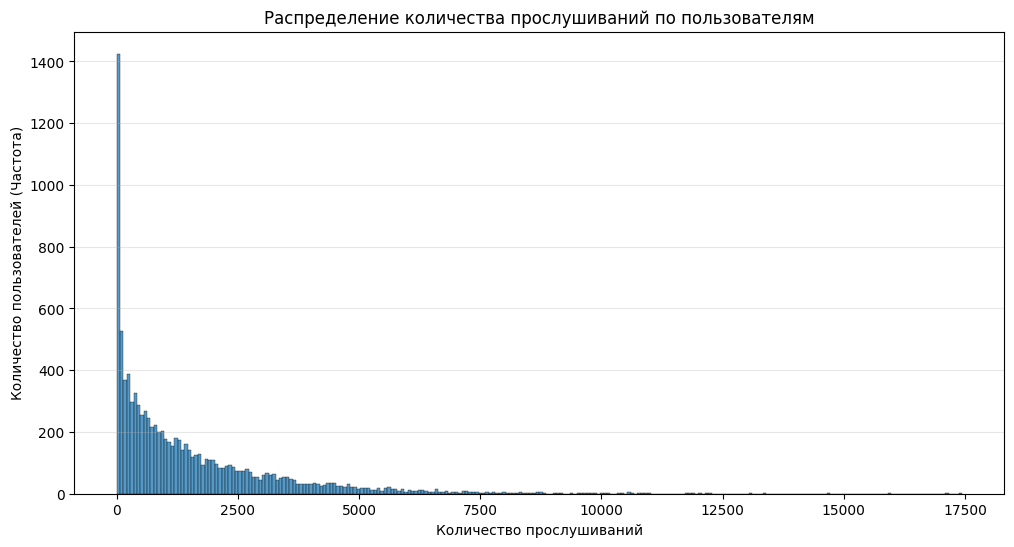

In [6]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, bins=250)

plt.title('Распределение количества прослушиваний по пользователям')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

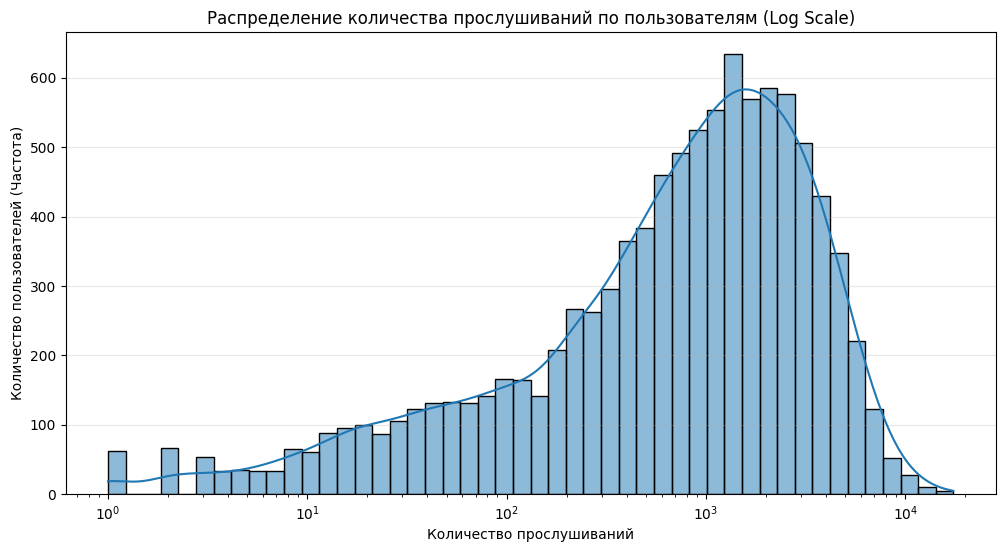

In [11]:
plt.figure(figsize=(12, 6))

sns.histplot(users_activity, log_scale=True, kde=True)

plt.title('Распределение количества прослушиваний по пользователям (Log Scale)')
plt.xlabel('Количество прослушиваний')
plt.ylabel('Количество пользователей (Частота)')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='count'>

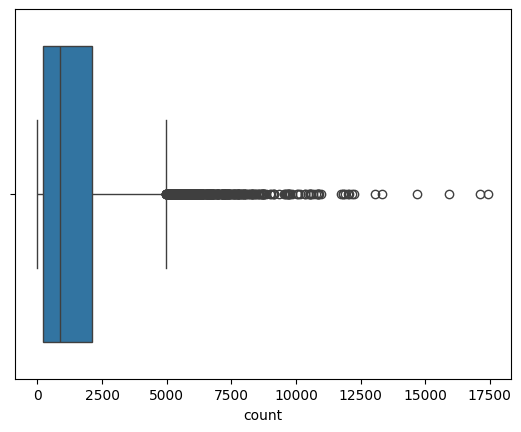

In [9]:
sns.boxplot(x=users_activity)

In [33]:
mean = np.mean(np.log(users_activity + 1))
std = np.std(np.log(users_activity + 1))
np.exp(mean - std), np.exp(mean + std)

(np.float64(96.08896420287124), np.float64(3432.937815758266))

In [13]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {users_activity.quantile(quantile)}')

Listens quntile 25.0%: 236.0
Listens quntile 50.0%: 888.0
Listens quntile 75.0%: 2124.0
Listens quntile 80.0%: 2542.0
Listens quntile 90.0%: 3742.0
Listens quntile 95.0%: 4900.699999999999
Listens quntile 99.0%: 7593.119999999999
Listens quntile 99.9%: 11896.785999999893


In [16]:
groups = pd.qcut(users_activity, q=[0, 0.25, 0.5, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Users activity distribution')
print(counts)

Users activity distribution
count
(0.999, 236.0]       2488
(236.0, 888.0]       2486
(888.0, 3742.0]      3975
(3742.0, 4900.7]      496
(4900.7, 17441.0]     498
Name: count, dtype: int64


Посмотрев на графики, количество прослушиваний и пользователей по квантилям, я думаю, что стоит оставить пользователей, которые по активности оказались между 25 и 95 квантилями

In [17]:
low_threshold = users_activity.quantile(0.25)
high_threshold = users_activity.quantile(0.95)

active_user_ids = users_activity[
    (users_activity >= low_threshold) & 
    (users_activity <= high_threshold)
].index

df_train_active = train_df[train_df['uid'].isin(active_user_ids)].reset_index(drop=True)

In [26]:
print('Unique User IDs at Train:', df_train_active['uid'].nunique())
print('Unique Item IDs at Train:', df_train_active['item_id'].nunique())
print(f'Unique Users decreased by {round((1 - df_train_active['uid'].nunique() / train_df['uid'].nunique()) * 100)} %')
print(f'Unique Items decreased by {round((1 - df_train_active['item_id'].nunique() / train_df['item_id'].nunique()) * 100)} %')


Unique User IDs at Train: 6963
Unique Item IDs at Train: 471099
Unique Users decreased by 30 %
Unique Items decreased by 11 %


Что еще можно проверить для юзеров:

- Можно выкинуть фанатов одного/пары треков
- Пользователей, у которых есть пики активности, за которыми следует спад
- Пользователей, которые лайкают почти все треки
- Неактивных пользователей (Последние полгода ничего не слушали)

Фанаты одного трека

Для анализа концентрации внимания пользователя будем использовать индекс Джини. Индекс нам покажет какую долю уникальные треки имеют из всех прослушиваний пользователя.

In [36]:
def gini(play_count):
    if len(play_count) == 0:
        return 0

    play_count = np.sort(play_count)
    index = np.arange(1, len(play_count) + 1)
    n = len(play_count)
    return ((np.sum((2 * index - n - 1) * play_count)) / (n * np.sum(play_count)))

In [37]:
user_item_counts = df_train_active.groupby(['uid', 'item_id']).size().reset_index(name='play_count')


user_gini = (
    user_item_counts
    .groupby('uid')['play_count']
    .apply(lambda x: gini(x.values))
    .reset_index(name='gini_index')
)

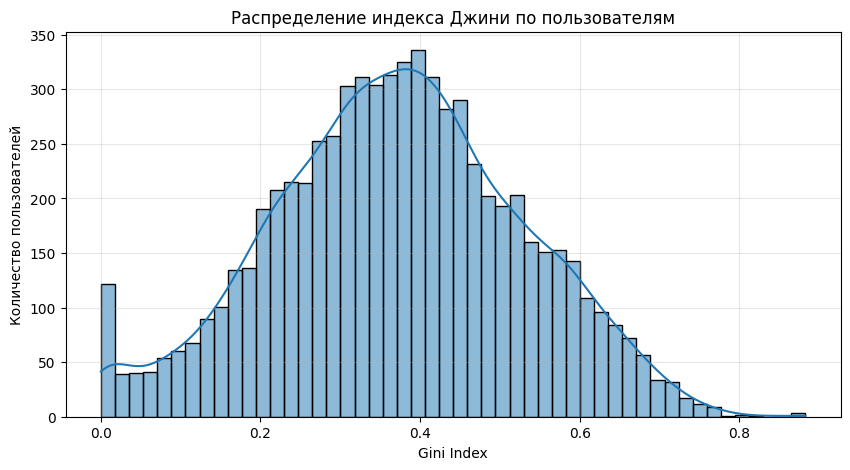

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(user_gini['gini_index'], bins=50, kde=True)
plt.title('Распределение индекса Джини по пользователям')
plt.xlabel('Gini Index')
plt.ylabel('Количество пользователей')
plt.grid(alpha=0.3)
plt.show()

In [41]:
user_gini['gini_index'].describe()

count    6963.000000
mean        0.371329
std         0.156090
min         0.000000
25%         0.267715
50%         0.372967
75%         0.475916
max         0.882941
Name: gini_index, dtype: float64

# Выводов добавить по Gini и насколько тут целесообразно было эту статистику смотреть в текущем сетапе, обосновать

Что проверить для айтемов:
- Выкинуть непопулярные айтемы
- Выкинуть айтемы, у которых высокий Skip Rate
- Старые треки (Recency vs. Lifetime), то есть проверять дату последнего взаимодействия